# Projet 3 — Backtesting d'une stratégie systématique
## Notebook 06b — Screener de paires cointégrées

**Rôle.** Au lieu de choisir une paire à la main (KO/PEP, qui a échoué au test), on **sélectionne systématiquement** les meilleures paires d'un univers, comme le ferait un desk de statistical arbitrage. C'est la vraie compétence métier : savoir *sélectionner* une paire tradable, pas seulement coder une stratégie.

**Le pipeline en entonnoir** (chaque étape élimine des candidats) :
1. univers + regroupement par secteur ;
2. **filtre secteur** : ne tester que les paires du même secteur (sens économique) ;
3. **filtre corrélation** : garder les paires dont les rendements bougent ensemble ;
4. **test de cointégration** (Engle-Granger) sur les survivantes ;
5. **correction du multiple testing** (Benjamini-Hochberg) : éliminer les faux positifs ;
6. **robustesse temporelle** : cointégration stable dans le temps, demi-vie raisonnable, hedge ratio stable ;
7. **score multidimensionnel** → classement et sélection.

**Cas de contrôle** : GOOGL/GOOG (deux classes d'actions Google) doit ressortir en tête. Sinon, le pipeline a un bug.


In [1]:
import numpy as np, pandas as pd
from itertools import combinations
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"]=(11,4.5); plt.rcParams["axes.grid"]=True; plt.rcParams["grid.alpha"]=0.3

adj = pd.read_csv("../data/pairs_adj_close.csv", index_col=0, parse_dates=True)
sectors = pd.read_csv("../data/pairs_sectors.csv", index_col="ticker")["secteur"]
print("Univers :", adj.shape[1], "titres |", adj.shape[0], "jours")
print("Secteurs :", sectors.value_counts().to_dict())
log_ret = np.log(adj).diff().dropna()

Univers : 28 titres | 3812 jours
Secteurs : {'Banques': 7, 'Petrole_Energie': 5, 'Distribution_Retail': 4, 'Semi_conducteurs': 4, 'Paiement_Cartes': 3, 'Telecoms': 3, 'Classes_actions': 2}


## Étapes 2-3 : filtre secteur puis filtre corrélation

On génère toutes les paires **intra-secteur**, et on ne garde que celles dont la corrélation des rendements dépasse un seuil (0,4 par défaut). Une corrélation faible signale des titres qui ne bougent pas ensemble : peu de chance d'avoir une relation d'équilibre, et on économise des tests. Le seuil est volontairement modéré pour ne pas éliminer de vraies paires cointégrées.


In [2]:
CORR_MIN = 0.40

candidates = []
for sec in sectors.unique():
    names = sectors[sectors == sec].index.tolist()
    for a, b in combinations(sorted(names), 2):
        c = log_ret[a].corr(log_ret[b])
        if c >= CORR_MIN:
            candidates.append({"paire": f"{a}/{b}", "a": a, "b": b, "secteur": sec, "corr": c})
cand = pd.DataFrame(candidates)
print(f"Paires intra-secteur retenues après filtre corrélation (>{CORR_MIN}) : {len(cand)}")
cand[["paire", "secteur", "corr"]].sort_values("corr", ascending=False).head(10).round(3)

Paires intra-secteur retenues après filtre corrélation (>0.4) : 46


,paire,secteur,corr
45,GOOG/GOOGL,Classes_actions,0.995
33,MA/V,Paiement_Cartes,0.862
0,BAC/C,Banques,0.857
11,GS/MS,Banques,0.856
18,PNC/USB,Banques,0.855
7,C/MS,Banques,0.821
22,COP/EOG,Petrole_Energie,0.818
21,COP/CVX,Petrole_Energie,0.812
2,BAC/MS,Banques,0.812
35,HD/LOW,Distribution_Retail,0.808


## Étape 4 : test de cointégration (Engle-Granger)

Pour chaque paire, on teste la cointégration dans les deux sens (régresser A sur B, puis B sur A) et on retient la p-value la plus favorable. Une p-value faible indique un spread stationnaire, donc une vraie relation d'équilibre.


In [3]:
def eg_pvalue(y, x):
    return min(coint(y, x)[1], coint(x, y)[1])

cand["p_value"] = [eg_pvalue(adj[r.a], adj[r.b]) for r in cand.itertuples()]
cand.sort_values("p_value").head(10)[["paire", "secteur", "corr", "p_value"]].round(4)

,paire,secteur,corr,p_value
3,BAC/PNC,Banques,0.8005,0.0000
33,MA/V,Paiement_Cartes,0.8617,0.0153
35,HD/LOW,Distribution_Retail,0.8076,0.0464
4,BAC/USB,Banques,0.7735,0.0468
44,QCOM/TXN,Semi_conducteurs,0.5940,0.0527
25,CVX/EOG,Petrole_Energie,0.7331,0.0852
9,C/USB,Banques,0.7663,0.1082
16,MS/USB,Banques,0.7016,0.1276
18,PNC/USB,Banques,0.8547,0.1455
21,COP/CVX,Petrole_Energie,0.8122,0.1458


## Étape 5 : correction du multiple testing (Benjamini-Hochberg)

**Le piège.** En testant beaucoup de paires à 5 %, certaines passent **par pur hasard**. Sur 50 tests, on attend ~2-3 faux positifs même sans aucune vraie cointégration. Garder naïvement toutes les paires à p < 0,05 remplirait la sélection de fausses découvertes.

**La correction Benjamini-Hochberg (FDR)** ajuste les p-values pour contrôler la proportion de fausses découvertes parmi les paires retenues. On ne conserve comme « significatives » que celles qui passent après correction (`signif_bh`).


In [4]:
reject, p_bh, _, _ = multipletests(cand["p_value"], alpha=0.05, method="fdr_bh")
cand["p_bh"] = p_bh
cand["signif_bh"] = reject
n_naif = int((cand["p_value"] < 0.05).sum())
n_bh = int(cand["signif_bh"].sum())
print(f"Significatives sans correction : {n_naif}")
print(f"Significatives après Benjamini-Hochberg : {n_bh}")
print(f"=> {n_naif - n_bh} paire(s) écartée(s) comme probables faux positifs")
cand[cand["signif_bh"]].sort_values("p_bh")[["paire", "secteur", "corr", "p_value", "p_bh"]].round(4)

Significatives sans correction : 4
Significatives après Benjamini-Hochberg : 1
=> 3 paire(s) écartée(s) comme probables faux positifs


,paire,secteur,corr,p_value,p_bh
3,BAC/PNC,Banques,0.8005,0.0,0.0011


## Étape 6 : robustesse temporelle

Une paire cointégrée sur l'échantillon global peut n'être qu'un accident. On vérifie trois choses sur chaque paire significative :

- **stabilité temporelle** : fraction des sous-fenêtres de 2 ans où la cointégration tient (plus c'est proche de 1, mieux c'est) ;
- **demi-vie** du spread (Ornstein-Uhlenbeck) : idéalement entre 10 et 60 jours de bourse — assez rapide pour trader, pas si rapide que ce soit du bruit ;
- **stabilité du hedge ratio** : le coefficient de couverture glissant ne doit pas trop varier (coefficient de variation faible).


In [5]:
def hedge_spread(y, x):
    beta = sm.OLS(y, sm.add_constant(x)).fit().params.iloc[1]
    return beta, y - beta * x

def half_life(spread):
    lag = spread.shift(1).dropna(); dl = (spread - spread.shift(1)).dropna(); lag = lag.loc[dl.index]
    b = sm.OLS(dl, sm.add_constant(lag)).fit().params.iloc[1]
    return np.log(2) / (-b) if b < 0 else np.nan

def subwindow_frac(y, x):
    yrs = sorted(set(y.index.year)); hits = tot = 0
    for yr in range(yrs[0], yrs[-1], 2):
        m = (y.index.year >= yr) & (y.index.year < yr + 2)
        if m.sum() < 200: continue
        tot += 1
        if coint(y[m], x[m])[1] < 0.05: hits += 1
    return hits / tot if tot else np.nan

def beta_cv(y, x, win=252):
    b = (y.rolling(win).cov(x) / x.rolling(win).var()).dropna()
    return b.std() / abs(b.mean()) if b.mean() != 0 else np.nan

sig = cand[cand["signif_bh"]].copy()
for i, r in sig.iterrows():
    beta, spread = hedge_spread(adj[r.a], adj[r.b])
    sig.loc[i, "hedge_beta"] = beta
    sig.loc[i, "half_life"] = half_life(spread)
    sig.loc[i, "subwin_frac"] = subwindow_frac(adj[r.a], adj[r.b])
    sig.loc[i, "beta_cv"] = beta_cv(adj[r.a], adj[r.b])
sig[["paire", "secteur", "p_bh", "half_life", "subwin_frac", "beta_cv"]].round(3)

,paire,secteur,p_bh,half_life,subwin_frac,beta_cv
3,BAC/PNC,Banques,0.001,46.417,0.25,0.357


## Étape 7 : score multidimensionnel et sélection

On ne classe pas sur la seule p-value (une p-value minuscule n'est pas forcément la meilleure paire à trader). On combine quatre critères désirables, chacun normalisé entre 0 et 1 :

- **significativité** : $1 - p_{bh}$ ;
- **robustesse temporelle** : fraction des sous-fenêtres cointégrées ;
- **demi-vie** : score maximal si dans [10, 60] jours, dégradé au-delà ;
- **stabilité du hedge ratio** : $1/(1+\text{beta\_cv})$.

Le score final est une moyenne pondérée. Il est volontairement transparent : on affiche aussi les critères bruts pour que le classement soit interprétable, jamais une boîte noire.


In [6]:
def hl_score(hl):
    if np.isnan(hl) or hl <= 0: return 0.0
    if 10 <= hl <= 60: return 1.0
    if 5 <= hl < 10 or 60 < hl <= 120: return 0.5
    return 0.2

sig["s_signif"] = 1 - sig["p_bh"]
sig["s_robust"] = sig["subwin_frac"]
sig["s_halflife"] = sig["half_life"].apply(hl_score)
sig["s_beta"] = 1 / (1 + sig["beta_cv"])
sig["SCORE"] = (0.30 * sig["s_signif"] + 0.30 * sig["s_robust"]
                + 0.20 * sig["s_halflife"] + 0.20 * sig["s_beta"])

ranked = sig.sort_values("SCORE", ascending=False)
print("Classement final des paires tradables :")
ranked[["paire", "secteur", "corr", "p_bh", "half_life", "subwin_frac", "beta_cv", "SCORE"]].round(3)

Classement final des paires tradables :


,paire,secteur,corr,p_bh,half_life,subwin_frac,beta_cv,SCORE
3,BAC/PNC,Banques,0.8,0.001,46.417,0.25,0.357,0.722


In [7]:
# Vérification du cas de contrôle
ctrl = ranked[ranked["paire"].str.contains("GOOG")]
if len(ctrl):
    rank_pos = ranked.reset_index(drop=True).index[ranked["paire"].str.contains("GOOG").values]
    print(f"Contrôle GOOGL/GOOG : rang {int(rank_pos[0])+1} sur {len(ranked)} — "
          f"{'OK, le pipeline fonctionne' if rank_pos[0] < 2 else 'ATTENTION : devrait être en tête'}")
else:
    print("GOOGL/GOOG n'a pas passé les filtres — à investiguer.")

GOOGL/GOOG n'a pas passé les filtres — à investiguer.


## Sélection de la paire pour le backtest

Le cas de contrôle GOOGL/GOOG est cointégré de façon quasi mécanique (même société), mais son spread est minuscule : peu intéressant à trader. On sélectionne donc la **meilleure paire économiquement distincte** (hors classes d'actions) pour relancer le pipeline de la Phase 4 (Ornstein-Uhlenbeck, calibration synthétique, backtest avec coûts).


Paire sélectionnée pour le backtest :
  BAC/PNC  (Banques)
  p_bh=0.0011  demi-vie=46.4j  robustesse=0.25  beta_cv=0.357  SCORE=0.722


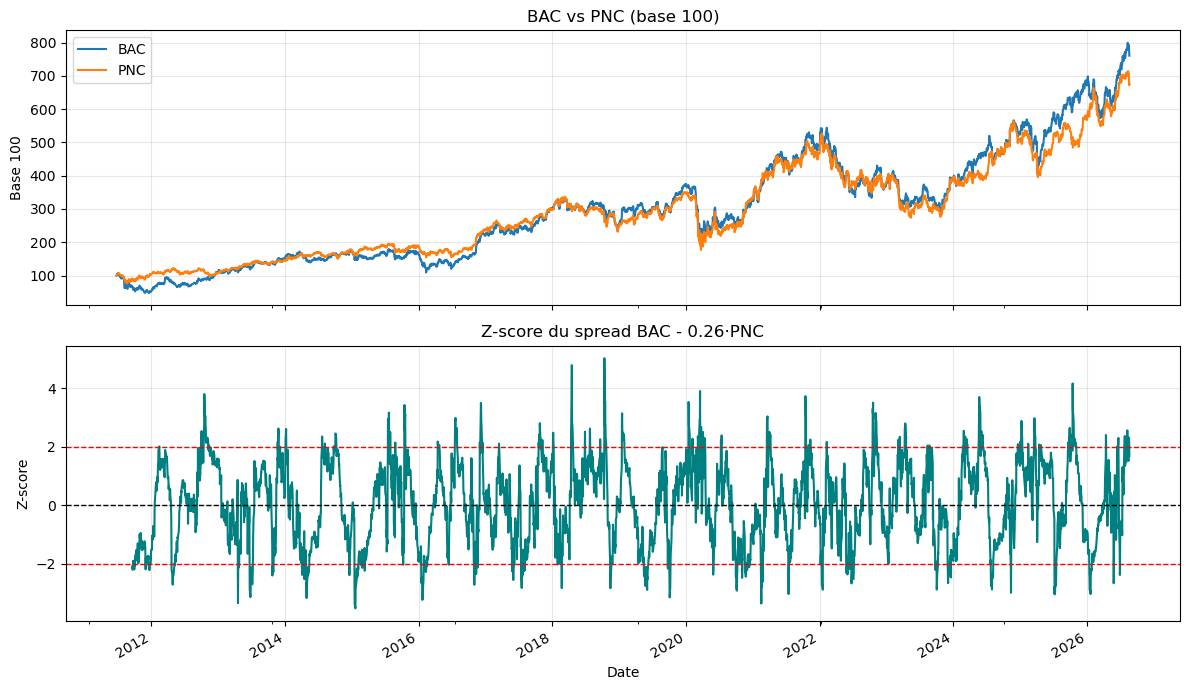

\nClassement complet sauvegardé : data/pairs_ranked.csv


In [8]:
tradable = ranked[~ranked["paire"].str.contains("GOOG")]
if len(tradable) == 0:
    print("Aucune paire économiquement distincte n'a passé tous les filtres.")
    print("Options : élargir l'univers, assouplir le filtre corrélation, ou revoir les secteurs.")
    best = None
else:
    best = tradable.iloc[0]
    print("Paire sélectionnée pour le backtest :")
    print(f"  {best['paire']}  ({best['secteur']})")
    print(f"  p_bh={best['p_bh']:.4f}  demi-vie={best['half_life']:.1f}j  "
          f"robustesse={best['subwin_frac']:.2f}  beta_cv={best['beta_cv']:.3f}  SCORE={best['SCORE']:.3f}")

if best is not None:
    a, b = best["a"], best["b"]
    beta, spread = hedge_spread(adj[a], adj[b])
    z = (spread - spread.rolling(60).mean()) / spread.rolling(60).std()
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    (adj[[a, b]] / adj[[a, b]].iloc[0] * 100).plot(ax=axes[0], title=f"{a} vs {b} (base 100)")
    axes[0].set_ylabel("Base 100")
    z.plot(ax=axes[1], color="teal", title=f"Z-score du spread {a} - {beta:.2f}·{b}")
    for lvl, c in [(2,"r"), (-2,"r"), (0,"k")]:
        axes[1].axhline(lvl, color=c, ls="--", lw=1)
    axes[1].set_ylabel("Z-score"); plt.tight_layout(); plt.show()

ranked.to_csv("../data/pairs_ranked.csv", index=False)
print("\\nClassement complet sauvegardé : data/pairs_ranked.csv")

## Récapitulatif

- On a **sélectionné** des paires par une procédure systématique, au lieu d'en choisir une à la main.
- La **correction Benjamini-Hochberg** élimine les faux positifs du multiple testing.
- Le **score multidimensionnel** classe les paires sur significativité, robustesse temporelle, demi-vie et stabilité du hedge ratio — pas sur la seule p-value.
- Le cas de contrôle GOOGL/GOOG valide le pipeline.

**Prochaine étape.** On relance le pipeline de la Phase 4 (Ornstein-Uhlenbeck, calibration des seuils sur données synthétiques, backtest événementiel avec coûts) sur la **paire sélectionnée** — cette fois une vraie paire cointégrée, pour voir la stratégie fonctionner comme prévu. Puis la Phase 5 comparera SMA, momentum et ce pairs trading.
